# Material for the chapter: Numerical methods

In [1]:
%matplotlib inline
import internal_script
#import dorion_francois.dfbook as df # path utils (etc.) for the book

import seaborn as sns

# Defines T, dt, n_days, and the figureXX functions among others
from dorion_francois.numerical_methods import *

## Simulating the diffusion model 

\begin{equation*}
  S_{t+1}=S_{t}
  \exp \left\lbrace 
      \left( r-y-\frac{\sigma ^{2}}{2}\right) \Delta{t} 
      + \sigma \sqrt{\Delta{t}}\varepsilon_{t} 
      \right\rbrace
\end{equation*}

In [2]:
T = 1 # in years
days_per_year = 252 # Assuming 252 business days in a year
dt = 1/days_per_year # A day
n_days = T*days_per_year # Total interval count
n_paths = 5000

S_0 = 100
rf = 0.05
div = 0.0
sigma = 0.4

time_t = np.arange(0,T+dt,dt) # The "end" is not included in Python arrays
epsilon = np.random.randn(n_days,n_paths)
R_t = np.exp((rf - div - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*epsilon)
S_t = S_0 * np.vstack((np.ones((1,n_paths)), R_t)).cumprod(axis=0)

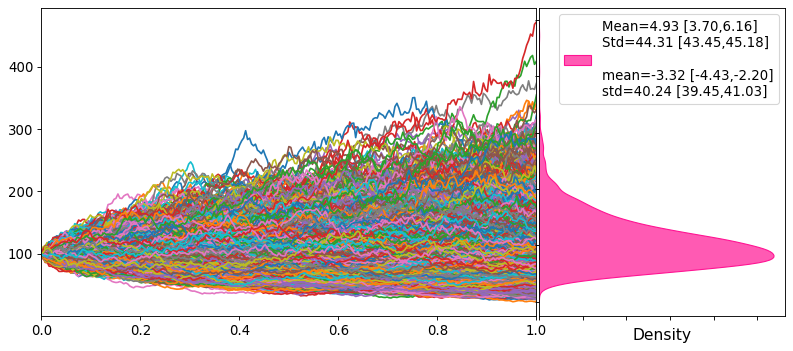

In [3]:
def ci_strings(ret):
    "95% confidence interval assuming that the CLT kicked in"
    mean = 100*np.mean(ret)
    std = 100*np.std(ret)
    
    denom = np.sqrt(n_paths) 
    mean_ci = [mean-1.96*std/denom, mean+1.96*std/denom]
    m_str = f'mean={mean:.2f} [{mean_ci[0]:.2f},{mean_ci[1]:.2f}]' 

    denom = np.sqrt(2*(n_paths-1))
    std_ci = [std-1.96*std/denom, std+1.96*std/denom]
    s_str = f'std={std:.2f} [{std_ci[0]:.2f},{std_ci[1]:.2f}]' 

    return m_str, s_str
    
def figure_sim_gbm(time_t, S_t, figsize=(12,5)):
    """Inspired from:
    
    https://www.machinelearningplus.com/plots/top-50-matplotlib-visualizations-the-master-plots-python/
    """
    #fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig = plt.figure(figsize=figsize, dpi=80)
    grid = plt.GridSpec(1, 3, wspace=0.01)

    ax_main = fig.add_subplot(grid[0:-1])
    ax_right = fig.add_subplot(grid[-1], xticklabels=[], yticklabels=[])

    ax_main.plot(time_t, S_t)
    ax_main.set_xlim(time_t[0],time_t[-1])
    
    #ax_right.hist(S_t[-1,:], 50, histtype='stepfilled', orientation='horizontal', color='deeppink')
    M_str,S_str = ci_strings(S_t[-1,:]/S_0 - 1)
    m_str,s_str = ci_strings(np.log(S_t[-1,:]/S_0))
    
    sns.kdeplot(y=S_t[-1,:], ax=ax_right, fill=True, color="deeppink", 
                label=f"{M_str.capitalize()}\n{S_str.capitalize()}\n\n{m_str}\n{s_str}", alpha=.7)
    ax_right.legend(loc='upper right')

figure_sim_gbm(time_t, S_t) 

**NOTE** the first line of the next cell: We here make use of interactive figures. Pretty slow however.

<IPython.core.display.Javascript object>


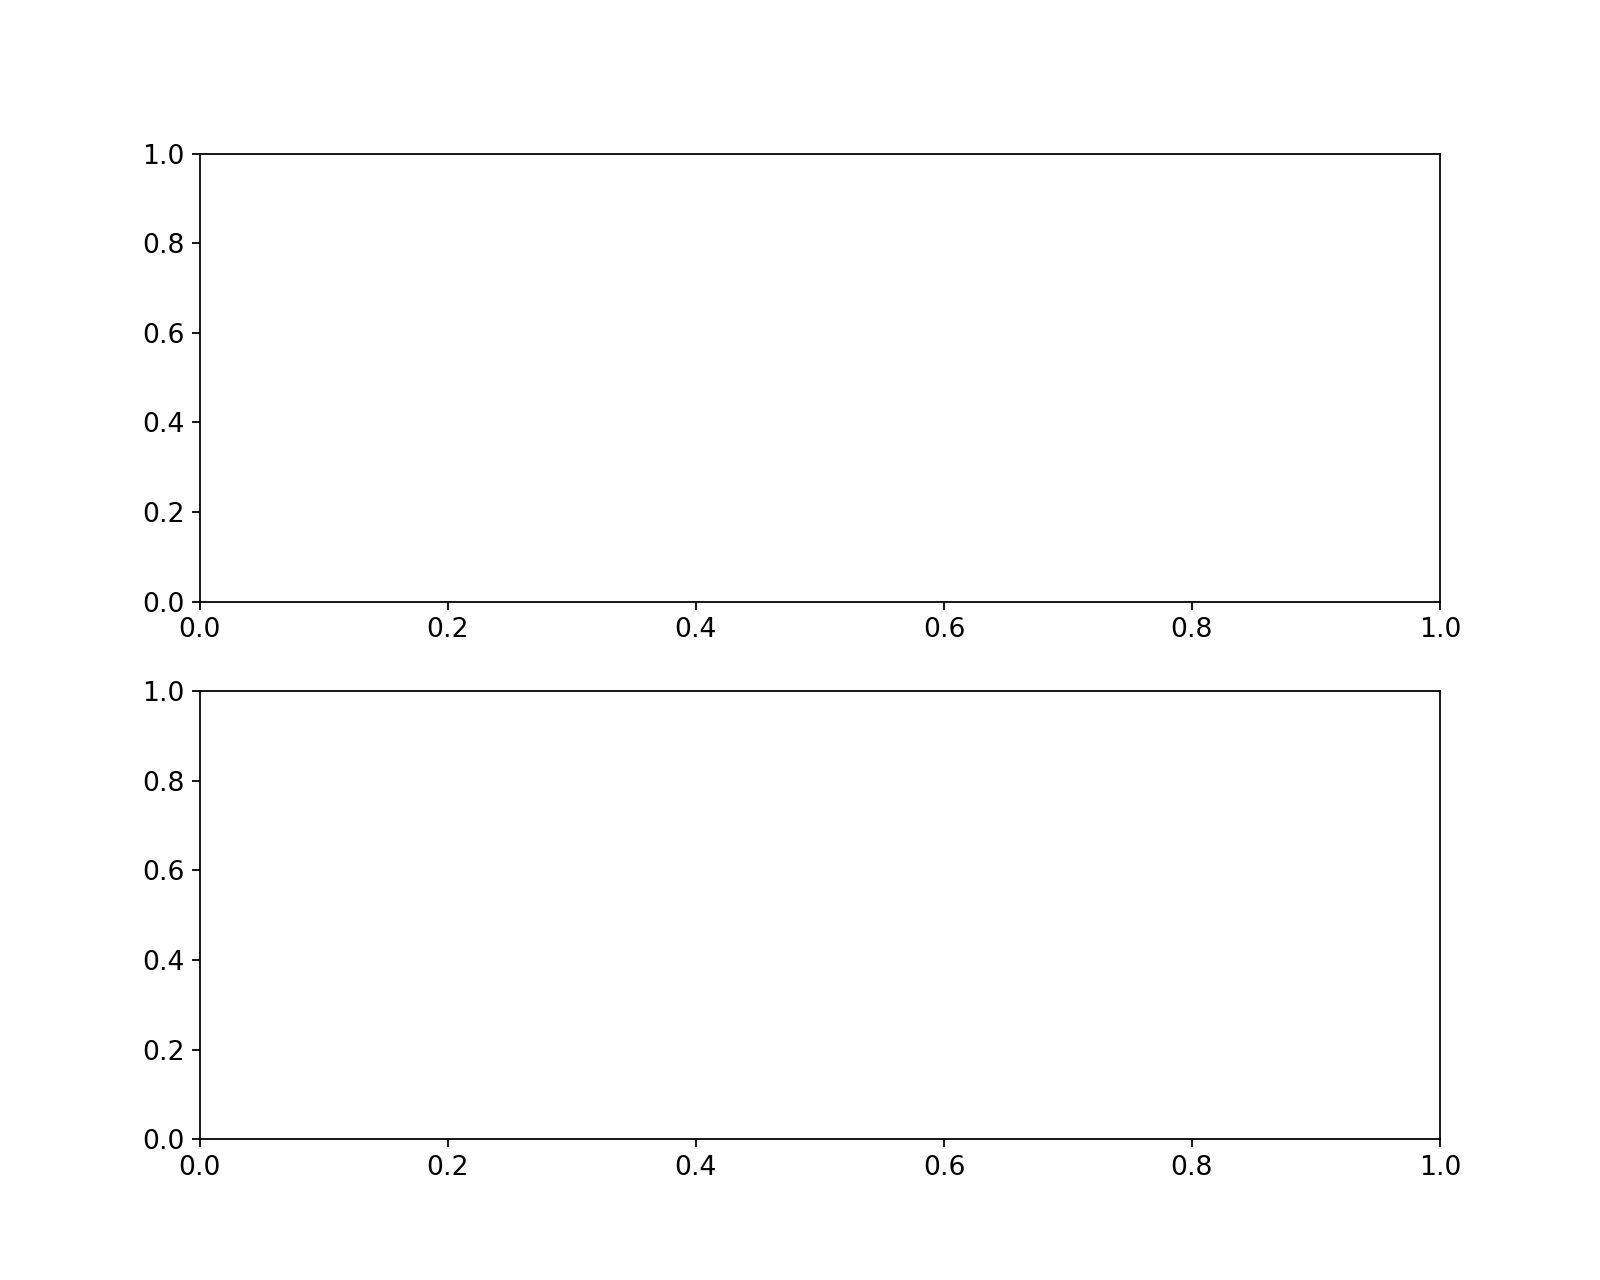

In [4]:
%matplotlib notebook

# Let's now consider antithetic variates
def compare_with_antithetic(no, axes):
    axes[0].clear()
    axes[1].clear()
    
    MC2 = int(n_paths/2)
    shocks = np.random.normal(0, 1, size=(n_days, n_paths))
    S_t = bms.simulate_underlying(S_0, rf, div, sigma, dt, shocks)

    # For each positive (negative) N(0,1) shock z, shock -z was equally likely. Consider the first half of the shocks,
    # and there additive inverse
    a_shocks = np.hstack((shocks[:,:MC2],-shocks[:,:MC2]))
    assert shocks.shape[1]==a_shocks.shape[1] # shocks and a_shocks contain the same number of paths
    Sa_t = bms.simulate_underlying(S_0, rf, div, sigma, dt, a_shocks)
        
    ax = axes[0]
    ax.plot(time_t, S_t)
    ax.axhline(S_0,color='w',linewidth=2)
    ax.set_title('Raw Simulation %d'%no)

    # What is the simulated forward price? How does it compare with the theoretical one?
    ax = axes[1]
    F_0_t = S_0*np.exp( rf*time_t );
    ax.plot(time_t, F_0_t, color='k', linestyle='--', label='Theory')
    ax.plot(time_t, S_t.mean(axis=1), color='#660000', label='Raw')
    ax.plot(time_t, Sa_t.mean(axis=1), color='#000066', label='Antithetic')
    ax.legend()
    ax.set_title('Forward Prices: Simulated vs Theory')
    fig.canvas.draw()
    
#fig, axes = plt.subplots(2, 1, figsize=(10,8))
fig = plt.figure(figsize=(10,8), dpi=80)
axes = [fig.add_subplot(g) for g in plt.GridSpec(2, 1, wspace=0.01)]

In [ ]:
compare_with_antithetic(1, axes)

Investigate this solution?

https://stackoverflow.com/a/30225272/21359768

In [ ]:
# We will perform multiple simulations with the same number of paths
NM = 100
PAUSE = 0.2*np.ones((NM,))
PAUSE[:10] = np.linspace(4,0.25,10)#.reshape(-1,1)
print(PAUSE.shape)
for no in range(2,NM+1):
    compare_with_antithetic(no,axes)
    #time.sleep(PAUSE[no-1])